# Sepsis Cases: analisi end-to-end con e senza logica

Questo notebook parte dal file XES originale e sviluppa l'intera pipeline:

1. caricamento e validazione dell'event log;
2. analisi descrittiva di casi, attività, tempi e varianti;
3. split per caso, evitando leakage;
4. costruzione di un DFA dai soli casi di training;
5. preparazione del task di **next-activity prediction**;
6. training di un GRU baseline;
7. training dello stesso GRU con una loss logica differenziabile;
8. confronto finale di accuratezza, F1, top-k e violazioni del DFA.

La logica non usa le etichette di test. Il DFA viene appreso esclusivamente dalle
transizioni osservate nel training set.

In [ ]:
%matplotlib inline

from pathlib import Path
import json
import random
import sys
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd()
if not (ROOT / "datasets").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.nspm.data.loader import read_xes
from src.nspm.pipeline.analysis import build_case_table, build_transition_table, SEPSIS_OUTCOME_MARKERS

DATA_PATH = ROOT / "datasets/Sepsis_Case/Sepsis_Cases_Event_Log.xes"
OUTPUT_DIR = ROOT / "datasets/Sepsis_Case/notebook_results"
MODEL_DIR = ROOT / "saved_models/Sepsis_Case"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Root:", ROOT)
print("Device:", DEVICE)
print("Dataset:", DATA_PATH)

## 1. Caricamento del dataset XES

Il parser usa `xml.etree.ElementTree.iterparse`, quindi legge una trace alla volta
senza mantenere l'intero XML in memoria. Ogni evento viene trasformato in una riga.

In [ ]:
# Lo schema della pipeline e' ora quello nativo pm4py (case:concept:name, ...).
# Qui rinominiamo al volo verso i nomi "amichevoli" usati nel resto del notebook,
# mantenendo `events_native` per le funzioni del package che si aspettano pm4py.
FRIENDLY = {
    "case:concept:name": "case_id",
    "concept:name": "activity",
    "time:timestamp": "timestamp",
    "org:group": "org_group",
    "lifecycle:transition": "lifecycle",
    "@@index": "event_index",
}
events_native = read_xes(DATA_PATH)
events = events_native.rename(columns=FRIENDLY)
events = events.sort_values(["case_id", "event_index"]).reset_index(drop=True)
cases = build_case_table(events_native,outcome_markers=SEPSIS_OUTCOME_MARKERS).rename(columns={"case:concept:name": "case_id"})

print(f"Casi: {events['case_id'].nunique():,}")
print(f"Eventi: {len(events):,}")
print(f"Attività: {events['activity'].nunique()}")
display(events.head())

## 2. Controlli di qualità

In [3]:
quality = pd.Series({
    "case_id mancanti": events["case_id"].isna().sum(),
    "attività mancanti": events["activity"].isna().sum(),
    "timestamp mancanti": events["timestamp"].isna().sum(),
    "eventi duplicati completi": events.duplicated().sum(),
    "timestamp non monotoni per caso": sum(
        not group["timestamp"].is_monotonic_increasing
        for _, group in events.groupby("case_id")
    ),
})
display(quality.to_frame("valore"))

,valore
case_id mancanti,0
attività mancanti,0
timestamp mancanti,0
eventi duplicati completi,0
timestamp non monotoni per caso,0


## 3. Analisi descrittiva

In [ ]:
activity_counts = events["activity"].value_counts()
variant_counts = cases["variant"].value_counts()
transitions = build_transition_table(events_native).rename(columns={"concept:name": "activity"})

summary = pd.DataFrame({
    "metrica": [
        "casi", "eventi", "attività", "varianti",
        "eventi medi per caso", "durata mediana (ore)",
        "casi Return ER", "casi Admission IC"
    ],
    "valore": [
        len(cases), len(events), events["activity"].nunique(),
        cases["variant"].nunique(), cases["event_count"].mean(),
        cases["duration_hours"].median(), cases["has_return_er"].sum(),
        cases["has_admission_ic"].sum(),
    ],
})
display(summary)

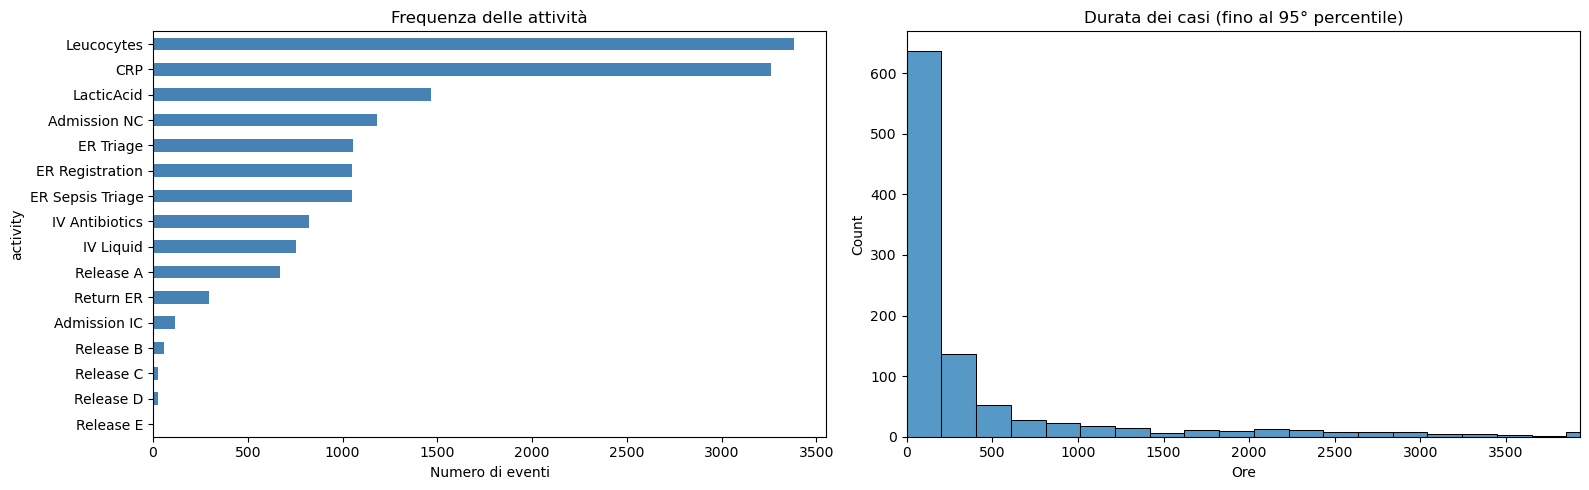

,casi
variant,
ER Registration > ER Triage > ER Sepsis Triage,35
ER Registration > ER Triage > ER Sepsis Triage > Leucocytes > CRP,24
ER Registration > ER Triage > ER Sepsis Triage > CRP > Leucocytes,22
ER Registration > ER Triage > ER Sepsis Triage > CRP > LacticAcid > Leucocytes > IV Liquid > IV Antibiotics,13
ER Registration > ER Triage > ER Sepsis Triage > Leucocytes > CRP > LacticAcid,11
ER Registration > ER Triage > ER Sepsis Triage > Leucocytes > CRP > LacticAcid > IV Liquid > IV Antibiotics,9
ER Registration > ER Triage > ER Sepsis Triage > Leucocytes > LacticAcid > CRP > IV Liquid > IV Antibiotics,7
ER Registration > ER Triage > CRP > Leucocytes > ER Sepsis Triage,5
ER Registration > ER Triage > ER Sepsis Triage > CRP > Leucocytes > LacticAcid > IV Liquid > IV Antibiotics,5


,activity,next_activity,count
93,Leucocytes,CRP,1778
28,CRP,Leucocytes,1445
37,ER Registration,ER Triage,971
52,ER Triage,ER Sepsis Triage,905
27,CRP,LacticAcid,629
87,LacticAcid,Leucocytes,565
73,IV Liquid,IV Antibiotics,501
58,IV Antibiotics,Admission NC,489
100,Leucocytes,Leucocytes,458
99,Leucocytes,LacticAcid,435


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
activity_counts.sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Frequenza delle attività")
axes[0].set_xlabel("Numero di eventi")

sns.histplot(cases["duration_hours"], bins=50, ax=axes[1])
axes[1].set_xlim(0, cases["duration_hours"].quantile(0.95))
axes[1].set_title("Durata dei casi (fino al 95° percentile)")
axes[1].set_xlabel("Ore")
plt.tight_layout()
plt.show()

display(variant_counts.head(10).rename("casi").to_frame())
display(transitions.head(15))

## 4. Split per caso

Lo split avviene prima della costruzione del DFA. In questo modo:

- eventi dello stesso paziente non finiscono in partizioni diverse;
- il DFA non vede transizioni di validation o test;
- le metriche misurano anche la capacità di gestire percorsi non osservati.

In [6]:
all_case_ids = cases["case_id"].to_numpy()
train_ids, temp_ids = train_test_split(
    all_case_ids, test_size=0.30, random_state=SEED
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50, random_state=SEED
)

split_map = {
    "train": set(train_ids),
    "validation": set(val_ids),
    "test": set(test_ids),
}

pd.DataFrame({
    "split": split_map.keys(),
    "casi": [len(value) for value in split_map.values()],
})

,split,casi
0,train,735
1,validation,157
2,test,158


## 5. Vocabolario delle azioni e DFA

Ogni attività è un'azione discreta. Il DFA empirico ha:

- uno stato iniziale `START`;
- uno stato per ciascuna ultima attività osservata;
- uno stato finale `END`;
- una transizione deterministica per ogni coppia directly-follows del training.

Una sequenza è accettata se parte da un'attività iniziale valida, usa solo
transizioni osservate nel training e termina con un'attività finale valida.

In [7]:
PAD = "<PAD>"
START = "<START>"
END = "<END>"
activities = sorted(events["activity"].dropna().unique())
tokens = [PAD, START] + activities
token_to_id = {token: index for index, token in enumerate(tokens)}
id_to_token = {index: token for token, index in token_to_id.items()}
PAD_ID = token_to_id[PAD]
START_ID = token_to_id[START]
NUM_CLASSES = len(activities)
class_ids = {activity: index for index, activity in enumerate(activities)}

def traces_for(case_ids):
    subset = events[events["case_id"].isin(case_ids)]
    return {
        case_id: group.sort_values("event_index")["activity"].tolist()
        for case_id, group in subset.groupby("case_id")
    }

train_traces = traces_for(split_map["train"])
val_traces = traces_for(split_map["validation"])
test_traces = traces_for(split_map["test"])

allowed_next = defaultdict(set)
start_actions = set()
end_actions = set()
for trace in train_traces.values():
    start_actions.add(trace[0])
    end_actions.add(trace[-1])
    allowed_next[START].add(trace[0])
    for current, nxt in zip(trace, trace[1:]):
        allowed_next[current].add(nxt)

dfa_graph = nx.DiGraph()
dfa_graph.add_node(START)
dfa_graph.add_node(END)
for activity in activities:
    dfa_graph.add_node(activity)
for state, next_values in allowed_next.items():
    for nxt in next_values:
        dfa_graph.add_edge(state, nxt)
for activity in end_actions:
    dfa_graph.add_edge(activity, END)

print("Stati DFA:", dfa_graph.number_of_nodes())
print("Transizioni DFA:", dfa_graph.number_of_edges())
print("Azioni iniziali:", sorted(start_actions))
print("Azioni finali:", sorted(end_actions))

Stati DFA: 18
Transizioni DFA: 128
Azioni iniziali: ['CRP', 'ER Registration', 'ER Sepsis Triage', 'ER Triage', 'IV Liquid', 'Leucocytes']
Azioni finali: ['Admission NC', 'CRP', 'ER Sepsis Triage', 'ER Triage', 'IV Antibiotics', 'IV Liquid', 'LacticAcid', 'Leucocytes', 'Release A', 'Release B', 'Release C', 'Release D', 'Release E', 'Return ER']


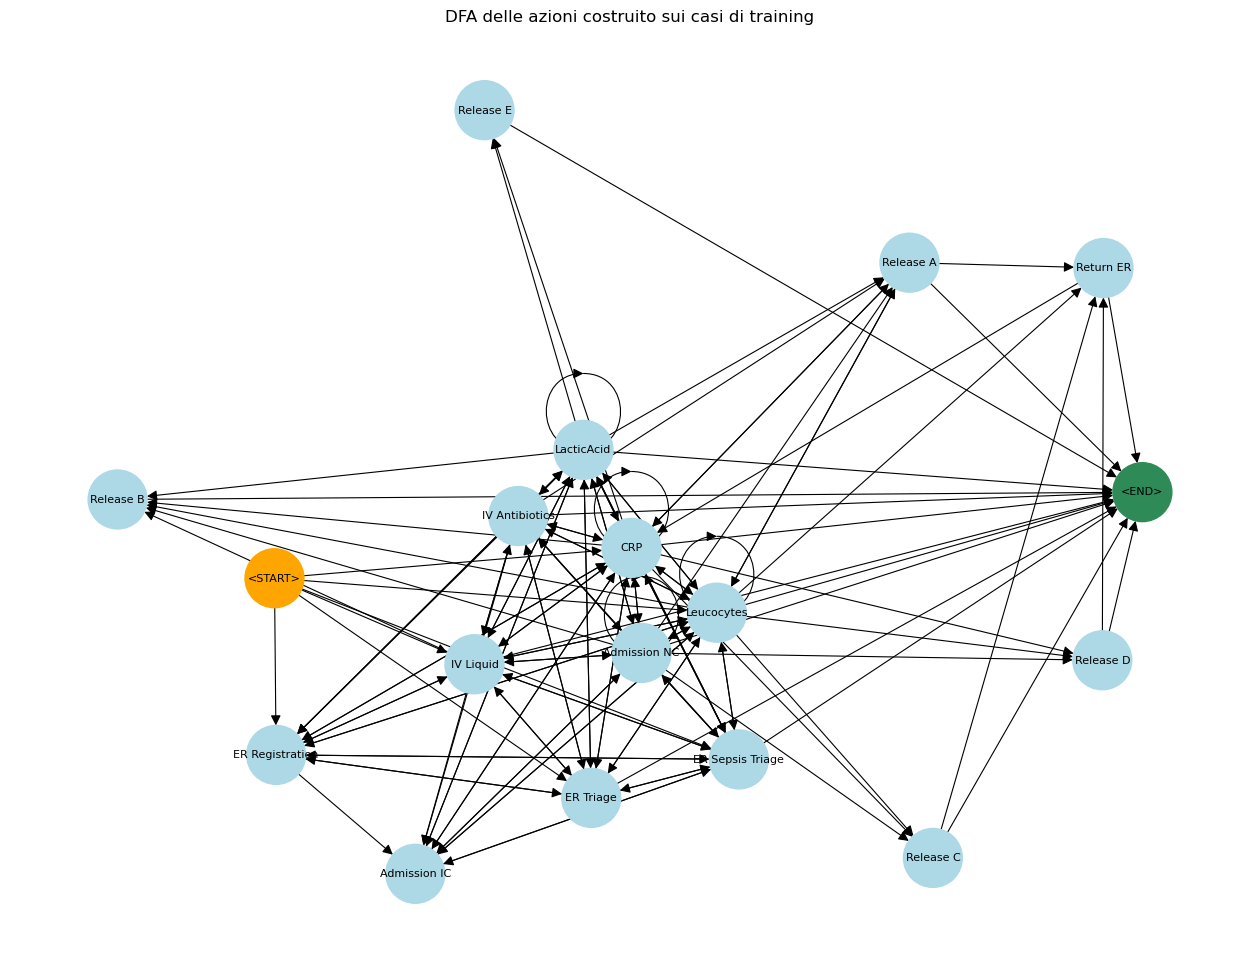

In [8]:
plt.figure(figsize=(16, 12))
position = nx.spring_layout(dfa_graph, seed=SEED, k=1.2)
node_colors = [
    "orange" if node == START else "seagreen" if node == END else "lightblue"
    for node in dfa_graph.nodes
]
nx.draw_networkx(
    dfa_graph,
    position,
    node_color=node_colors,
    node_size=1800,
    font_size=8,
    arrowsize=15,
    width=0.8,
)
plt.title("DFA delle azioni costruito sui casi di training")
plt.axis("off")
plt.show()

## 6. Dataset per la previsione della prossima azione

Da una trace `[a1, a2, a3]` otteniamo:

- input `[START]` → target `a1`;
- input `[START, a1]` → target `a2`;
- input `[START, a1, a2]` → target `a3`.

Il modello vede quindi tutti i prefissi clinici disponibili.

In [9]:
def make_examples(trace_dict):
    examples = []
    for case_id, trace in trace_dict.items():
        prefix = [START_ID]
        for action in trace:
            examples.append((case_id, prefix.copy(), class_ids[action]))
            prefix.append(token_to_id[action])
    return examples

train_examples = make_examples(train_traces)
val_examples = make_examples(val_traces)
test_examples = make_examples(test_traces)

class PrefixDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index):
        return self.examples[index]

def collate_batch(batch):
    case_ids, prefixes, targets = zip(*batch)
    lengths = torch.tensor([len(prefix) for prefix in prefixes], dtype=torch.long)
    padded = torch.full((len(prefixes), int(lengths.max())), PAD_ID, dtype=torch.long)
    for row, prefix in enumerate(prefixes):
        padded[row, : len(prefix)] = torch.tensor(prefix)
    return list(case_ids), padded, lengths, torch.tensor(targets, dtype=torch.long)

def loader(examples, shuffle=False):
    return DataLoader(
        PrefixDataset(examples),
        batch_size=128,
        shuffle=shuffle,
        collate_fn=collate_batch,
    )

train_loader = loader(train_examples, shuffle=True)
val_loader = loader(val_examples)
test_loader = loader(test_examples)

pd.DataFrame({
    "split": ["train", "validation", "test"],
    "prefissi": [len(train_examples), len(val_examples), len(test_examples)],
})

,split,prefissi
0,train,10740
1,validation,2315
2,test,2159


## 7. Maschera logica differenziabile

Per ogni ultima azione del prefisso costruiamo una maschera binaria delle azioni
ammesse dal DFA. La loss logica è la probabilità totale assegnata ad azioni vietate:

`logic_loss = Σ P(azione vietata | prefisso)`

La configurazione logic-aware minimizza:

`cross_entropy + λ × logic_loss`

In [10]:
allowed_mask = torch.zeros(len(tokens), NUM_CLASSES, dtype=torch.float32)
for state, next_values in allowed_next.items():
    state_id = START_ID if state == START else token_to_id[state]
    for activity in next_values:
        allowed_mask[state_id, class_ids[activity]] = 1.0

# Fallback: uno stato senza uscite non deve produrre una loss infinita.
empty_rows = allowed_mask.sum(dim=1) == 0
allowed_mask[empty_rows] = 1.0
allowed_mask = allowed_mask.to(DEVICE)

def logic_penalty(logits, last_tokens):
    probabilities = logits.softmax(dim=-1)
    valid = allowed_mask[last_tokens]
    forbidden_mass = (probabilities * (1.0 - valid)).sum(dim=-1)
    return forbidden_mass.mean()

def prediction_violation_rate(predictions, last_tokens):
    valid = allowed_mask[last_tokens]
    rows = torch.arange(len(predictions), device=predictions.device)
    return (valid[rows, predictions] == 0).float()

## 8. Modello sequenziale

In [11]:
class NextActivityGRU(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, tokens, lengths):
        embedded = self.embedding(tokens)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        return self.classifier(hidden[-1])

def last_tokens_from_batch(tokens, lengths):
    rows = torch.arange(tokens.size(0), device=tokens.device)
    return tokens[rows, lengths.to(tokens.device) - 1]

## 9. Training baseline e logic-aware

In [12]:
def evaluate(model, data_loader):
    model.eval()
    targets_all, predictions_all, probabilities_all = [], [], []
    violations_all, forbidden_mass_all = [], []
    total_loss = 0.0
    with torch.no_grad():
        for _, tokens_batch, lengths, targets in data_loader:
            tokens_batch = tokens_batch.to(DEVICE)
            lengths = lengths.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(tokens_batch, lengths)
            total_loss += F.cross_entropy(logits, targets, reduction="sum").item()
            probabilities = logits.softmax(dim=-1)
            predictions = probabilities.argmax(dim=-1)
            last_tokens = last_tokens_from_batch(tokens_batch, lengths)
            violations = prediction_violation_rate(predictions, last_tokens)
            valid = allowed_mask[last_tokens]
            forbidden_mass = (probabilities * (1.0 - valid)).sum(dim=-1)
            targets_all.extend(targets.cpu().tolist())
            predictions_all.extend(predictions.cpu().tolist())
            probabilities_all.extend(probabilities.cpu().tolist())
            violations_all.extend(violations.cpu().tolist())
            forbidden_mass_all.extend(forbidden_mass.cpu().tolist())

    targets_np = np.asarray(targets_all)
    predictions_np = np.asarray(predictions_all)
    probabilities_np = np.asarray(probabilities_all)
    top3 = np.mean([
        target in np.argsort(probability)[-3:]
        for target, probability in zip(targets_np, probabilities_np)
    ])
    return {
        "loss": total_loss / len(targets_np),
        "accuracy": accuracy_score(targets_np, predictions_np),
        "macro_f1": f1_score(targets_np, predictions_np, average="macro", zero_division=0),
        "top3_accuracy": float(top3),
        "dfa_violation_rate": float(np.mean(violations_all)),
        "forbidden_probability_mass": float(np.mean(forbidden_mass_all)),
        "targets": targets_np,
        "predictions": predictions_np,
    }

def train_model(use_logic, logic_weight=0.5, epochs=12):
    torch.manual_seed(SEED)
    model = NextActivityGRU(len(tokens), NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-5)
    history = []
    best_state = None
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        running_ce = 0.0
        running_logic = 0.0
        examples_seen = 0
        for _, tokens_batch, lengths, targets in train_loader:
            tokens_batch = tokens_batch.to(DEVICE)
            lengths = lengths.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(tokens_batch, lengths)
            ce = F.cross_entropy(logits, targets)
            last_tokens = last_tokens_from_batch(tokens_batch, lengths)
            constraint = logic_penalty(logits, last_tokens)
            loss = ce + logic_weight * constraint if use_logic else ce

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            batch_size = targets.size(0)
            running_ce += ce.item() * batch_size
            running_logic += constraint.item() * batch_size
            examples_seen += batch_size

        validation = evaluate(model, val_loader)
        history.append({
            "epoch": epoch,
            "train_ce": running_ce / examples_seen,
            "train_logic": running_logic / examples_seen,
            "val_loss": validation["loss"],
            "val_accuracy": validation["accuracy"],
            "val_violation": validation["dfa_violation_rate"],
        })
        if validation["loss"] < best_val:
            best_val = validation["loss"]
            best_state = {key: value.detach().cpu() for key, value in model.state_dict().items()}
        print(
            f"{'logic' if use_logic else 'baseline'} epoch={epoch:02d} "
            f"val_loss={validation['loss']:.4f} "
            f"val_acc={validation['accuracy']:.3f} "
            f"viol={validation['dfa_violation_rate']:.3f}"
        )

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

start = time.time()
baseline_model, baseline_history = train_model(use_logic=False)
logic_model, logic_history = train_model(use_logic=True, logic_weight=0.5)
print(f"Tempo totale training: {time.time() - start:.1f}s")

torch.save(baseline_model.state_dict(), MODEL_DIR / "next_activity_baseline.pt")
torch.save(logic_model.state_dict(), MODEL_DIR / "next_activity_logic.pt")

baseline epoch=01 val_loss=1.1841 val_acc=0.608 viol=0.000


baseline epoch=02 val_loss=1.0140 val_acc=0.655 viol=0.000


baseline epoch=03 val_loss=0.9659 val_acc=0.667 viol=0.000


baseline epoch=04 val_loss=0.9409 val_acc=0.661 viol=0.000


baseline epoch=05 val_loss=0.9190 val_acc=0.664 viol=0.000


...

logic epoch=08 val_loss=0.9068 val_acc=0.666 viol=0.000


logic epoch=09 val_loss=0.8996 val_acc=0.671 viol=0.000


logic epoch=10 val_loss=0.8966 val_acc=0.662 viol=0.000


logic epoch=11 val_loss=0.8990 val_acc=0.664 viol=0.000


logic epoch=12 val_loss=0.8844 val_acc=0.667 viol=0.000
Tempo totale training: 21.0s


## 10. Curve di apprendimento

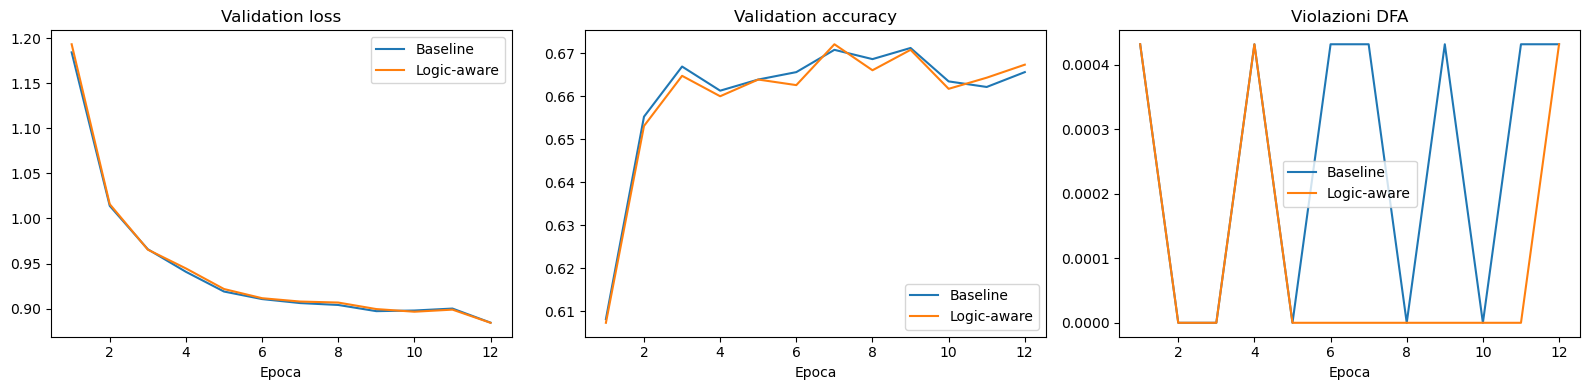

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, history in [("Baseline", baseline_history), ("Logic-aware", logic_history)]:
    axes[0].plot(history["epoch"], history["val_loss"], label=name)
    axes[1].plot(history["epoch"], history["val_accuracy"], label=name)
    axes[2].plot(history["epoch"], history["val_violation"], label=name)

axes[0].set_title("Validation loss")
axes[1].set_title("Validation accuracy")
axes[2].set_title("Violazioni DFA")
for axis in axes:
    axis.set_xlabel("Epoca")
    axis.legend()
plt.tight_layout()
plt.show()

## 11. Risultati sul test set

In [14]:
baseline_test = evaluate(baseline_model, test_loader)
logic_test = evaluate(logic_model, test_loader)

metric_names = [
    "loss",
    "accuracy",
    "macro_f1",
    "top3_accuracy",
    "dfa_violation_rate",
    "forbidden_probability_mass",
]
comparison = pd.DataFrame(
    {
        "Baseline": [baseline_test[name] for name in metric_names],
        "Logic-aware": [logic_test[name] for name in metric_names],
    },
    index=metric_names,
)
comparison["Differenza (logic - baseline)"] = (
    comparison["Logic-aware"] - comparison["Baseline"]
)
display(comparison)
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv")

,Baseline,Logic-aware,Differenza (logic - baseline)
loss,0.854808,0.854222,-0.000586
accuracy,0.677165,0.679481,0.002316
macro_f1,0.498685,0.498351,-0.000334
top3_accuracy,0.935155,0.932376,-0.002779
dfa_violation_rate,0.000000,0.000000,0.000000
forbidden_probability_mass,0.003435,0.002466,-0.000969


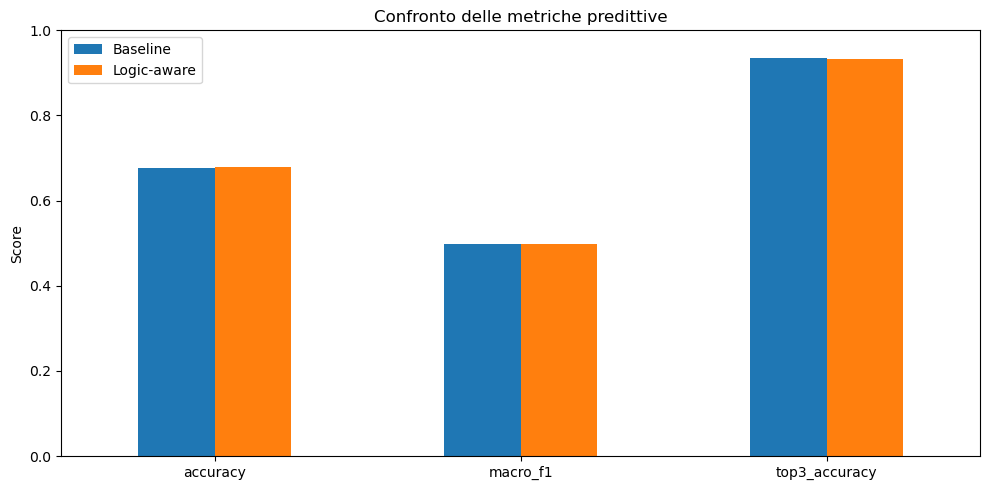

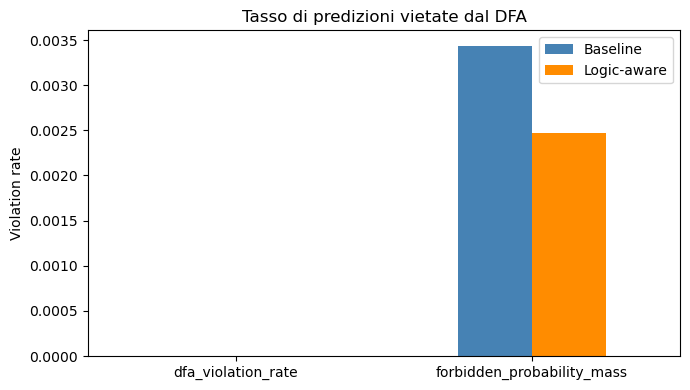

In [15]:
plot_metrics = ["accuracy", "macro_f1", "top3_accuracy"]
comparison.loc[plot_metrics, ["Baseline", "Logic-aware"]].plot.bar(
    figsize=(10, 5), ylim=(0, 1), rot=0
)
plt.title("Confronto delle metriche predittive")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

comparison.loc[
    ["dfa_violation_rate", "forbidden_probability_mass"],
    ["Baseline", "Logic-aware"],
].plot.bar(
    figsize=(7, 4), rot=0, color=["steelblue", "darkorange"]
)
plt.title("Tasso di predizioni vietate dal DFA")
plt.ylabel("Violation rate")
plt.tight_layout()
plt.show()

## 12. Confusion matrix e analisi per azione

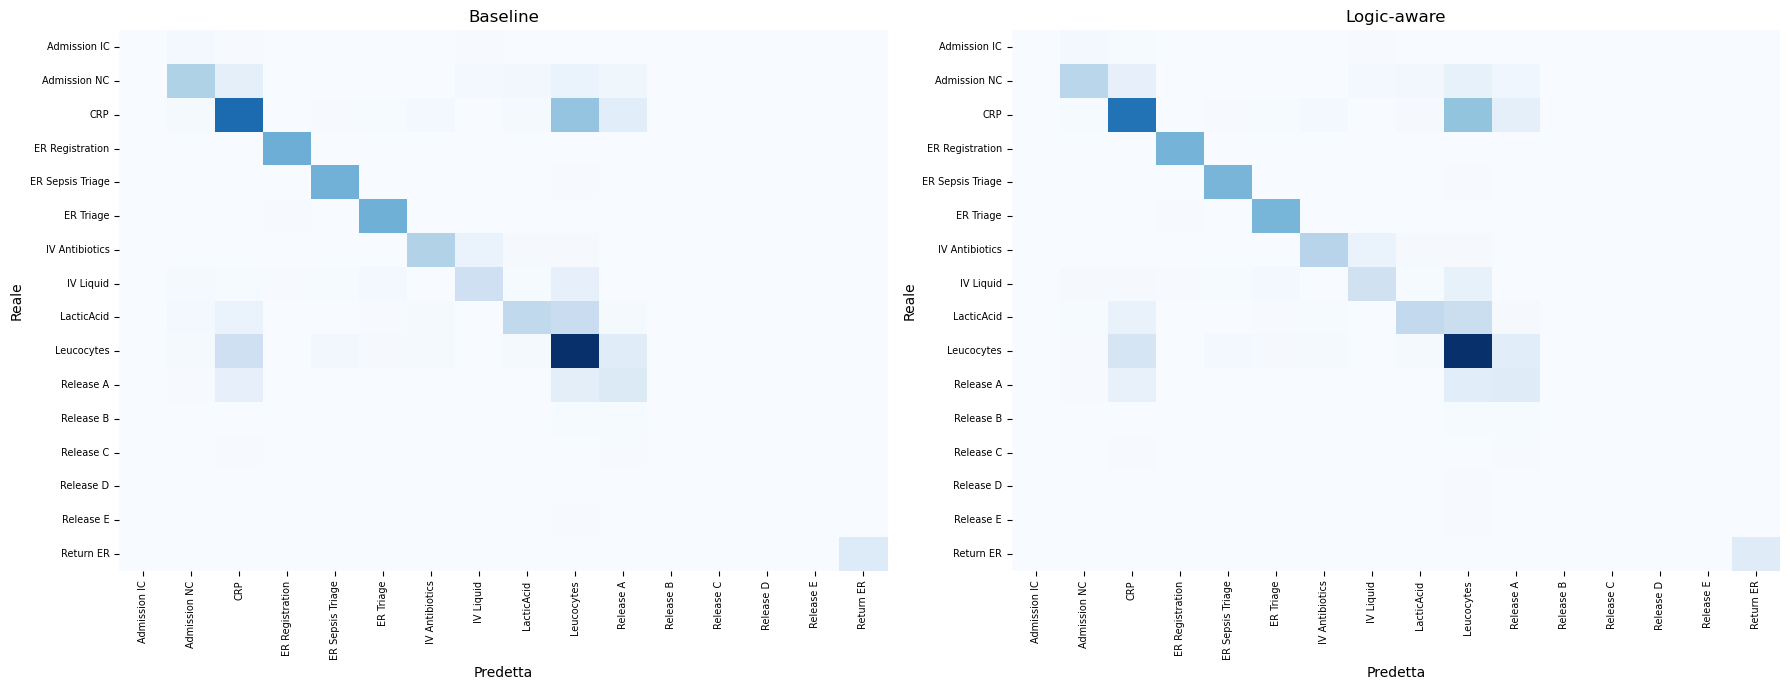

,precision,recall,f1-score,support
Admission IC,0.000000,0.000000,0.000000,14.0
Release D,0.000000,0.000000,0.000000,2.0
Release E,0.000000,0.000000,0.000000,2.0
Release B,0.000000,0.000000,0.000000,8.0
Release C,0.000000,0.000000,0.000000,4.0
Release A,0.302326,0.378641,0.336207,103.0
macro avg,0.517140,0.492605,0.498351,2159.0
LacticAcid,0.731092,0.435000,0.545455,200.0
CRP,0.628205,0.569767,0.597561,430.0
Leucocytes,0.512422,0.731707,0.602740,451.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for axis, title, result in [
    (axes[0], "Baseline", baseline_test),
    (axes[1], "Logic-aware", logic_test),
]:
    matrix = confusion_matrix(
        result["targets"], result["predictions"], labels=range(NUM_CLASSES)
    )
    sns.heatmap(matrix, ax=axis, cmap="Blues", cbar=False)
    axis.set_title(title)
    axis.set_xlabel("Predetta")
    axis.set_ylabel("Reale")
    axis.set_xticks(np.arange(NUM_CLASSES) + 0.5)
    axis.set_yticks(np.arange(NUM_CLASSES) + 0.5)
    axis.set_xticklabels(activities, rotation=90, fontsize=7)
    axis.set_yticklabels(activities, rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

logic_report = pd.DataFrame(
    classification_report(
        logic_test["targets"],
        logic_test["predictions"],
        labels=range(NUM_CLASSES),
        target_names=activities,
        output_dict=True,
        zero_division=0,
    )
).T
display(logic_report.sort_values("f1-score").head(10))
logic_report.to_csv(OUTPUT_DIR / "logic_classification_report.csv")

## 13. Copertura del DFA e interpretazione

Il DFA è costruito solo sul training set. Calcoliamo quante transizioni reali dei
casi di test non erano mai apparse durante il training. Questo valore rappresenta
il limite del vincolo: una regola troppo rigida può penalizzare percorsi clinici
validi ma rari.

In [17]:
def trace_transition_coverage(trace_dict):
    total = 0
    unseen = 0
    unseen_pairs = Counter()
    for trace in trace_dict.values():
        previous = START
        for current in trace:
            total += 1
            if current not in allowed_next[previous]:
                unseen += 1
                unseen_pairs[(previous, current)] += 1
            previous = current
    return unseen / total, unseen_pairs

test_unseen_rate, unseen_pairs = trace_transition_coverage(test_traces)
print(f"Transizioni reali di test non viste nel training: {test_unseen_rate:.3%}")
display(
    pd.DataFrame(
        [(a, b, count) for (a, b), count in unseen_pairs.most_common(15)],
        columns=["da", "a", "conteggio"],
    )
)

Transizioni reali di test non viste nel training: 0.093%


,da,a,conteggio
0,Leucocytes,Release E,1
1,Release E,Return ER,1


## 14. Conclusioni

Il confronto va interpretato su due assi:

- **prestazioni predittive**: accuracy, macro-F1 e top-3;
- **coerenza di processo**: tasso di transizioni vietate dal DFA.

Il modello logic-aware è utile quando riduce le violazioni senza compromettere
eccessivamente le metriche predittive. Se il DFA ha copertura incompleta, il peso
`logic_weight` deve essere validato e non imposto arbitrariamente.

In [18]:
final_results = {
    "dataset": {
        "cases": int(events["case_id"].nunique()),
        "events": int(len(events)),
        "activities": int(len(activities)),
    },
    "dfa": {
        "states": int(dfa_graph.number_of_nodes()),
        "transitions": int(dfa_graph.number_of_edges()),
        "test_unseen_transition_rate": float(test_unseen_rate),
    },
    "baseline": {name: float(baseline_test[name]) for name in metric_names},
    "logic_aware": {name: float(logic_test[name]) for name in metric_names},
}

with (OUTPUT_DIR / "final_results.json").open("w", encoding="utf-8") as handle:
    json.dump(final_results, handle, indent=2)

display(pd.DataFrame(final_results["dataset"].items(), columns=["Dataset", "Valore"]))
print("Modelli salvati in:", MODEL_DIR)
print("Risultati salvati in:", OUTPUT_DIR)

,Dataset,Valore
0,cases,1050
1,events,15214
2,activities,16


Modelli salvati in: /mnt/c/Users/Matteo/PycharmProjects/T-LEAF/saved_models/Sepsis_Case
Risultati salvati in: /mnt/c/Users/Matteo/PycharmProjects/T-LEAF/datasets/Sepsis_Case/notebook_results
